## 🟢 Part 1 — Basic Linear Regression

In [317]:
import pandas as pd

df = pd.DataFrame({
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Marks": [35, 40, 50, 55, 65, 70, 80, 85]
})

print(df)

   Hours  Marks
0      1     35
1      2     40
2      3     50
3      4     55
4      5     65
5      6     70
6      7     80
7      8     85


In [318]:
#Dataset mein:
# Feature X kya hoga?
# Target y kya hoga?

X=df[["Hours"]]
y=df["Marks"]

print(X)
print(y)

   Hours
0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
0    35
1    40
2    50
3    55
4    65
5    70
6    80
7    85
Name: Marks, dtype: int64


In [319]:
# Q3. 80:20 Train-Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [320]:
# Q4. Linear Regression model create karo

from sklearn.linear_model import LinearRegression

model=LinearRegression()

In [321]:
# Q5. Model ko train karo

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.3]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [322]:
# Q6. Test data par prediction

y_pred=model.predict(X_test)

print(y_pred)

[42.2 71.4]


In [323]:
# Q7. Actual aur predicted values print karo

print("Actual",y_test.values)
print("Predicted",y_pred)

Actual [40 70]
Predicted [42.2 71.4]


In [324]:
# Q8. 9 hours study karne par marks predict karo

prediction = model.predict([[9]])

print("Predicted Marks",prediction[0])

Predicted Marks 93.29999999999998


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [325]:
# Q9. Intercept aur coefficient print karo

print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 27.60000000000001
Coefficient: [7.3]


In [326]:
#Q10. Coefficient ka meaning

model.coef_=[7]

## Part 3 — Model Evaluation

In [327]:
# Q11. MAE calculate karo

from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 1.7999999999999972


In [328]:
# Q12. MSE calculate karo

from sklearn.metrics import mean_squared_error

mse= mean_squared_error(y_test,y_pred)
print("Mse",mse)

Mse 3.399999999999994


In [329]:
# Q13. RMSE calculate karo

rmse=mse**0.5

print("Rmse:",rmse)
    # ya ye 
# rmse = mean_squared_error(y_test, y_pred) ** 0.5

Rmse: 1.843908891458576


In [330]:
# Q14. R² calculate karo

from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)


R2 Score: 0.9848888888888889


In [331]:
# Q15. Sabhi metrics ek saath

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.7999999999999972
MSE: 3.399999999999994
RMSE: 1.843908891458576
R2: 0.9848888888888889


## Part 4 — Multiple Linear Regression

In [332]:
df = pd.DataFrame({
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Sleep": [8, 7, 7, 6, 6, 5, 5, 4],
    "Attendance": [90, 85, 88, 80, 82, 78, 75, 70],
    "Marks": [35, 42, 50, 55, 65, 68, 78, 82]
})

In [333]:
# Q16. X aur y separate karo

X=df[["Hours","Sleep","Attendance"]]
y=df["Marks"]

In [334]:
# Q17. 80:20 split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [335]:
# Q18. Linear Regression model

from sklearn.linear_model import LinearRegression

model=LinearRegression()

In [336]:
# Q19. Model train karo

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 8.98, 4.62,-0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Hours','Sleep','Attendance']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.526
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [337]:
# Q20. Prediction

y_pred=model.predict(X_test)

print(y_pred)

[83.31578947 49.59398496]


In [338]:
# Q21. MAE

from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,y_pred)

print("MAE",mae)

MAE 0.860902255639111


In [339]:
# Q22. MSE

from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_test,y_pred)
print("MSE",mse)

MSE 0.9480750749053274


In [340]:
# Q23. RMSE

rmse=mse**0.5
print(mse)

0.9480750749053274


In [341]:
# Q24. R²

from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)
print("R2",r2)

R2 0.9962965817386511


In [342]:
# Q25. Coefficients print karo

print(model.coef_)

[ 8.97744361  4.62406015 -0.15037594]


In [343]:
# Q26. Intercept

print("Intercept:", model.intercept_)

Intercept: 3.526315789473827


## Part 5 — New Student Prediction

In [344]:
# Q27. Hours=6, Sleep=7, Attendance=85

prediction = model.predict([[6,7,85]])

print("Predicted Marks:",prediction[0])

Predicted Marks: 76.97744360902254


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [345]:
# Q28. Do students ki prediction
# Student 1:,Hours = 5,Sleep = 6,Attendance = 80
# Student 2: Hours = 8,Sleep = 7,Attendance = 90

students=[[5,6,80],
          [8,7,90]]

prediction = model.predict(students)
print(prediction)

[64.12781955 94.18045113]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Part 6 — Train vs Test



In [346]:
# Q29. Training predictions

y_train_pred=model.predict(X_train)

print(y_train_pred)

[41.06766917 78.21052632 35.96240602 63.82706767 55.15037594 68.78195489]


In [347]:
# Q30. Training aur testing R²

from sklearn.metrics import r2_score

train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_pred)

print("Train R2:",train_r2)
print("Test R2:",test_r2)

Train R2: 0.9971246428033235
Test R2: 0.9962965817386511


In [348]:
# # Q31. Train R² = 0.99, Test R² = 0.45

# Model training data ko bahut achhe se learn kar raha hai, lekin unseen 
# test data par performance kaafi lower hai.

## Part 7 — Visualization

### Q32. Actual points ka scatter plot

Text(0, 0.5, 'Marks')

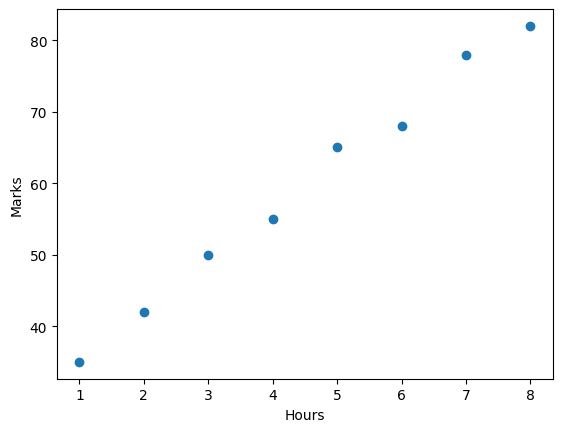

In [349]:
import matplotlib.pyplot as plt 

plt.scatter(df["Hours"],df["Marks"])
plt.xlabel("Hours")
plt.ylabel("Marks")

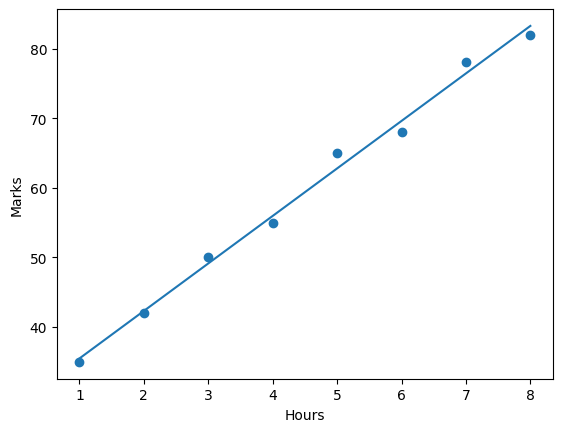

In [350]:
# Q33. Regression line
# pahile hum model train karenge hours pe 

X=df[["Hours"]]
y=df["Marks"]

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

import matplotlib.pyplot as plt

plt.scatter(df["Hours"], df["Marks"])

plt.plot(df["Hours"],model.predict(df[["Hours"]]))

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.show()



Text(0.5, 1.0, 'Hours vs Marks')

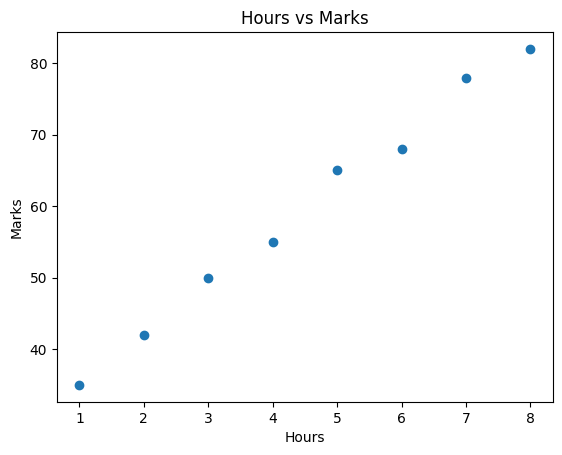

In [352]:
# Q34. Axes Hours vs Marks

plt.scatter(df["Hours"],df["Marks"])

plt.xlabel("Hours")
plt.ylabel("Marks")

plt.title("Hours vs Marks")

